# BPSK over an AWGN channel

This notebook builds a reproducible bit-error-rate (BER) experiment with `pyberlab`. It demonstrates the complete workflow: inspect the BPSK constellation, run an adaptive Monte-Carlo simulation, compare it with the analytical result, export the data, and save a publication-ready figure.

## System model

BPSK maps bits $0$ and $1$ to the real symbols $-1$ and $+1$. For coherent detection over additive white Gaussian noise (AWGN), the theoretical BER is

$$P_b = Q\!\left(\sqrt{2E_b/N_0}\right) = \frac{1}{2}\operatorname{erfc}\!\left(\sqrt{E_b/N_0}\right).$$

The simulation uses unit symbol energy, hard decisions at zero, and a fixed random seed.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "pyberlab").exists():
            return candidate
    raise RuntimeError("Run this notebook from inside the pyberlab repository.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
from pyberlab.channel import awgn
from pyberlab.modulation import BPSK
from pyberlab.plot import plot_ber
from pyberlab.simulation import run_simulation

OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CSV_PATH = OUTPUT_DIR / "bpsk_awgn_notebook.csv"
FIGURE_PATH = OUTPUT_DIR / "bpsk_awgn_notebook.png"
SEED = 42
EBN0_DB = np.arange(0, 11)

print("Results will be saved in: outputs/")

Results will be saved in: outputs/


## Inspect the constellation

The two constellation points have unit magnitude and are separated by the decision threshold at zero.

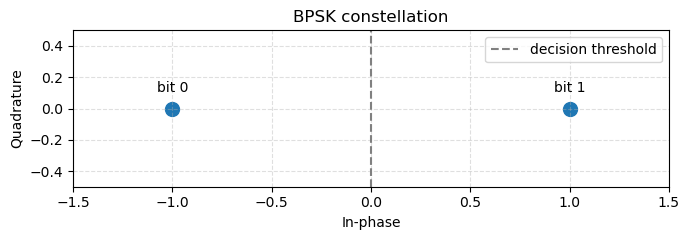

In [3]:
modulator = BPSK()
constellation = modulator.modulate(np.array([0, 1]))

fig, ax = plt.subplots(figsize=(7, 2.5))
ax.scatter(constellation, np.zeros_like(constellation), s=100)
for bit, symbol in enumerate(constellation):
    ax.annotate(f"bit {bit}", (symbol, 0), xytext=(0, 12), textcoords="offset points", ha="center")
ax.axvline(0, color="gray", linestyle="--", label="decision threshold")
ax.set(xlim=(-1.5, 1.5), ylim=(-0.5, 0.5), xlabel="In-phase", ylabel="Quadrature", title="BPSK constellation")
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend()
fig.tight_layout()
plt.show()

## Run the BER experiment

`run_simulation` chooses the number of bits independently at every $E_b/N_0$ point. It targets at least 200 expected errors for useful statistics, while `max_bits` keeps the high-SNR points bounded in time and memory.

In [4]:
results = run_simulation(
    modulator,
    awgn,
    EBN0_DB,
    seed=SEED,
    min_errors=200,
    max_bits=2_000_000,
    csv_path=CSV_PATH,
)

print(f"Saved {len(results['EbN0_dB'])} SNR points to {CSV_PATH.relative_to(PROJECT_ROOT)}")

Saved 11 SNR points to outputs\bpsk_awgn_notebook.csv


In [5]:
print(f"{'Eb/N0 (dB)':>10} {'BER sim':>13} {'BER theory':>13} {'bits':>11} {'errors':>8}")
print("-" * 61)
for ebn0, simulated, theoretical, n_bits, n_errors in zip(
    results["EbN0_dB"],
    results["ber_sim"],
    results["ber_theory"],
    results["n_bits"],
    results["n_errors"],
):
    print(f"{ebn0:10.1f} {simulated:13.6g} {theoretical:13.6g} {n_bits:11,d} {n_errors:8,d}")

Eb/N0 (dB)       BER sim    BER theory        bits   errors
-------------------------------------------------------------
       0.0       0.07987     0.0786496     100,000    7,987
       1.0       0.05556      0.056282     100,000    5,556
       2.0       0.03829     0.0375061     100,000    3,829
       3.0       0.02248     0.0228784     100,000    2,248
       4.0       0.01309     0.0125008     100,000    1,309
       5.0        0.0061    0.00595387     100,000      610
       6.0       0.00251    0.00238829     100,000      251
       7.0   0.000741768   0.000772675     258,841      192
       8.0   0.000199499   0.000190908   1,047,626      209
       9.0       3.5e-05   3.36272e-05   2,000,000       70
      10.0       1.5e-06   3.87211e-06   2,000,000        3


## Check statistical agreement

Monte-Carlo BER is random. A useful diagnostic is the difference between simulation and theory measured in binomial standard errors. Values of a few standard errors are normal; high-SNR points fluctuate more when the bit cap prevents collecting the target number of errors.

In [6]:
ber_sim = np.asarray(results["ber_sim"])
ber_theory = np.asarray(results["ber_theory"])
n_bits = np.asarray(results["n_bits"])
standard_error = np.sqrt(ber_theory * (1 - ber_theory) / n_bits)
z_scores = np.abs(ber_sim - ber_theory) / standard_error

print(f"Largest simulation/theory difference: {z_scores.max():.2f} standard errors")
print(f"Mean absolute BER difference: {np.mean(np.abs(ber_sim - ber_theory)):.3e}")

Largest simulation/theory difference: 1.70 standard errors
Mean absolute BER difference: 3.659e-04


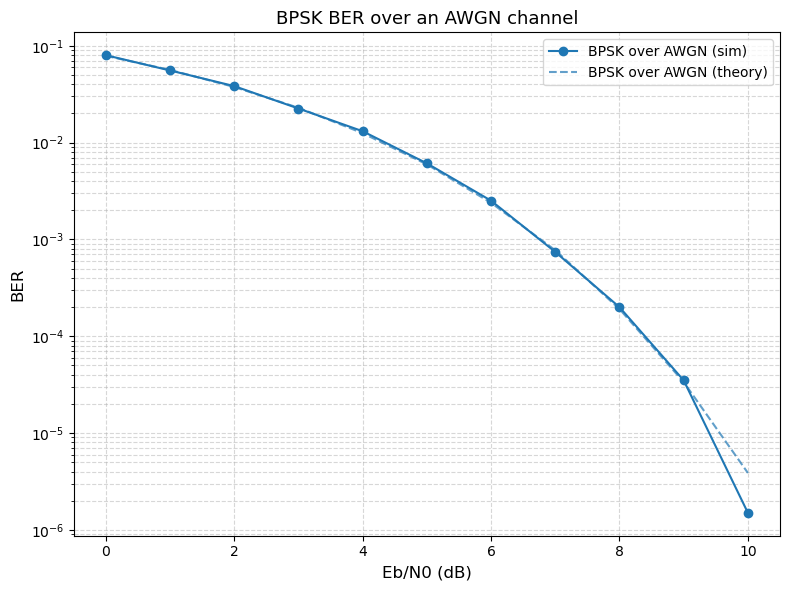

Saved figure to outputs\bpsk_awgn_notebook.png


In [7]:
plot_ber(
    [results],
    ["BPSK over AWGN"],
    title="BPSK BER over an AWGN channel",
    save_path=FIGURE_PATH,
    show=False,
)
plt.show()
print(f"Saved figure to {FIGURE_PATH.relative_to(PROJECT_ROOT)}")

## Interpretation

The simulated markers should follow the dashed analytical curve. BER falls rapidly with increasing $E_b/N_0$ because the two BPSK symbols become easier to separate relative to the noise variance. At the highest SNR values, only a small number of errors may be observed before the bit cap is reached, so relative Monte-Carlo variation becomes more visible.

### Suggested experiments

- Change `SEED` and confirm that the theoretical curve is unchanged while the simulated markers move slightly.
- Increase `max_bits` to improve high-SNR accuracy and observe the runtime trade-off.
- Replace `awgn` with `rayleigh` and compare the slower BER decay under fading.
- Replace `BPSK` with `QPSK`, `PSK8`, `QAM16`, or `QAM64`.